In [ ]:
# (a) Collect data about their returns (based on closing price) for the last 12 months

import yfinance as yf
import pandas as pd

# Define the list of stock tickers
stocks = [
    'AAPL', 'NVDA', 'NET', 'BL', 'SHOP', 'ROKU', 'DKNG', 'EA', 'AMZN', 'META',
    'SPOT', 'MSFT', 'SONY', 'DIS', 'NFLX', 'TSLA', 'F', 'SHAK', 'MCD', 'GOOG'
]

# Download adjusted closing prices for the specified stocks
data = yf.download(stocks, start='2023-11-17', end='2024-11-17')['Adj Close']
stocks=sorted(stocks) #sort stocks alphabetically
data.to_csv("stocks.csv") #optional, if you want to transfer the data to excel and perform the analysis in Excel

[*********************100%***********************]  20 of 20 completed


In [ ]:
 # (b) Compute the average return and the covariance matrix.

 # Calculate daily returns
daily_returns = data.pct_change()
# Calculate mean returns and covariance matrix
mean_returns = daily_returns.mean()
cov_matrix = daily_returns.cov()

print(mean_returns)
print(cov_matrix)

mean_returns.to_csv("mean_return.csv")
cov_matrix.to_csv("cov_matrix.csv")

Ticker
AAPL    0.000803
AMZN    0.001481
BL      0.000472
DIS     0.000969
DKNG    0.000517
EA      0.000834
F       0.000825
GOOG    0.001103
MCD     0.000397
META    0.002280
MSFT    0.000560
NET     0.001274
NFLX    0.002453
NVDA    0.004771
ROKU   -0.000589
SHAK    0.003206
SHOP    0.002392
SONY    0.000414
SPOT    0.004089
TSLA    0.001980
dtype: float64
Ticker      AAPL      AMZN        BL       DIS      DKNG        EA         F  \
Ticker                                                                         
AAPL    0.000202  0.000082  0.000076  0.000015  0.000065  0.000028  0.000032   
AMZN    0.000082  0.000295  0.000112  0.000035  0.000209  0.000033  0.000082   
BL      0.000076  0.000112  0.000549  0.000038  0.000164  0.000045  0.000164   
DIS     0.000015  0.000035  0.000038  0.000272  0.000097  0.000032  0.000087   
DKNG    0.000065  0.000209  0.000164  0.000097  0.000732  0.000048  0.000134   
EA      0.000028  0.000033  0.000045  0.000032  0.000048  0.000120  0.000038  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 83.2 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2026-11-23


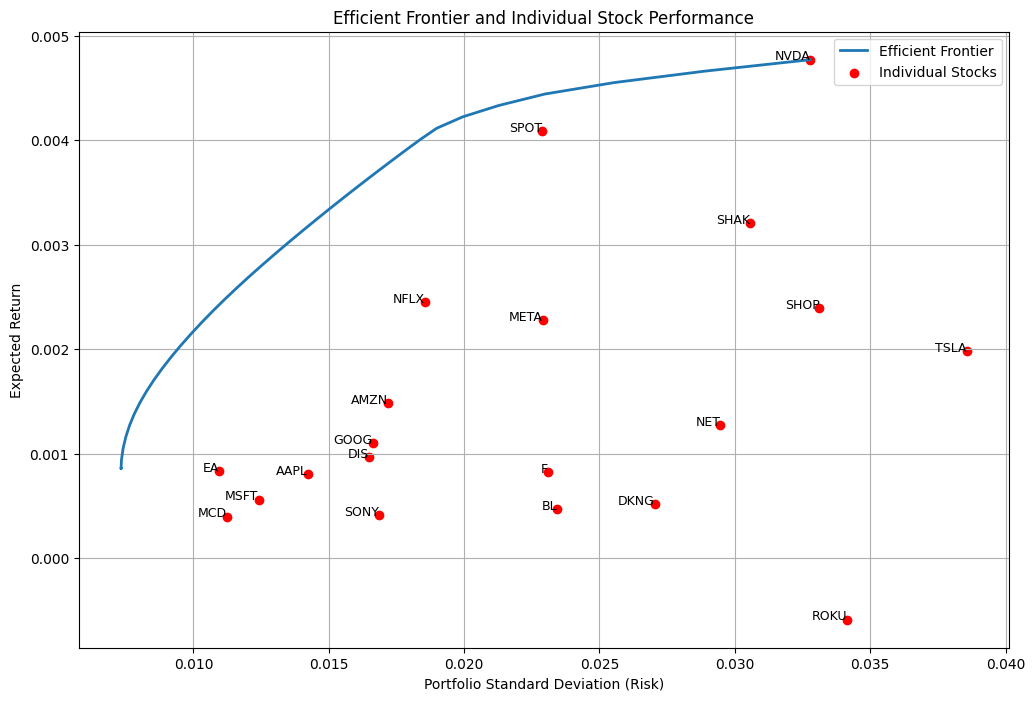

In [ ]:
# (c) Plot the efficient frontier of your optimal portfolio of minimum variance.
!pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt

# Number of stocks
n = len(stocks)

# Function to find the minimum variance portfolio for a given target return
def min_variance_portfolio(target_return):
    # Create a Gurobi model
    m = gp.Model("Min_Variance_Portfolio")
    m.setParam('OutputFlag', 0)  # Suppress output

    # Add variables for the weights of the stocks (w_i)
    weights = m.addVars(n, lb=0, ub=1, name="weights")

    # Set the objective to minimize portfolio variance: w' * Cov * w
    portfolio_variance = sum(cov_matrix.iloc[i, j] * weights[i] * weights[j]
                             for i in range(n) for j in range(n))
    m.setObjective(portfolio_variance, GRB.MINIMIZE)

    # Add constraint: Sum of weights = 1 (i.e., fully invested)
    m.addConstr(sum(weights[i] for i in range(n)) == 1, "Budget")

    # Add constraint: Target return
    portfolio_return = sum(mean_returns.iloc[i] * weights[i] for i in range(n))
    m.addConstr(portfolio_return >= target_return, "Target_Return")

    # Optimize the model
    m.optimize()

    # If optimal, extract the portfolio variance and return
    if m.status == GRB.OPTIMAL:
        return np.sqrt(m.ObjVal), sum(mean_returns.iloc[i] * weights[i].X for i in range(n))
    else:
        return None, None

# Define a range of target returns
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

# Calculate the corresponding portfolio standard deviations and returns
std_devs = []
eff_returns = []
for tr in target_returns:
    std_dev, eff_return = min_variance_portfolio(tr)
    if not np.isnan(std_dev):
        std_devs.append(std_dev)
        eff_returns.append(eff_return)

# Calculate individual stock performance (standard deviation and expected return)
stock_std_devs = daily_returns.std()
stock_returns = mean_returns

# Plot the efficient frontier and individual stock performances
plt.figure(figsize=(12, 8))

# Plot the efficient frontier
plt.plot(std_devs, eff_returns, label='Efficient Frontier', linewidth=2)

# Plot individual stocks as a scatter plot
plt.scatter(stock_std_devs, stock_returns, color='red', marker='o', label='Individual Stocks')

# Annotate individual stocks
for i, ticker in enumerate(stocks):
    plt.annotate(ticker, (stock_std_devs.iloc[i], stock_returns.iloc[i]), fontsize=9, ha='right')

# Add labels and title
plt.xlabel('Portfolio Standard Deviation (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier and Individual Stock Performance')
plt.grid(True)
plt.legend()
plt.show()





In [ ]:
# (d) Set your target return to be equal to the average return across all stocks. What is your optimal portfolio?

# Target returns = average returns
target_return = mean_returns.mean()

m = gp.Model("Min_Variance_Portfolio")
m.setParam('OutputFlag', 0)  # Suppress output

# Add variables for the weights of the stocks (w_i)
weights = m.addVars(n, lb=0, ub=1, name="weights")

# Set the objective to minimize portfolio variance: w' * Cov * w
portfolio_variance = sum(cov_matrix.iloc[i, j] * weights[i] * weights[j]
                             for i in range(n) for j in range(n))
m.setObjective(portfolio_variance, GRB.MINIMIZE)

# Add constraint: Sum of weights = 1 (i.e., fully invested)
m.addConstr(sum(weights[i] for i in range(n)) == 1, "Budget")

# Add constraint: Target return
portfolio_return = sum(mean_returns.iloc[i] * weights[i] for i in range(n))
m.addConstr(portfolio_return >= target_return, "Target_Return")

# Optimize the model
m.optimize()

# Extract the optimal weights and expected return of the portfolio
if m.status == GRB.OPTIMAL:
    optimal_weights = [weights[i].X for i in range(n)]
    optimal_return = sum(mean_returns.iloc[i] * optimal_weights[i] for i in range(n))

# Display the optimal portfolio weights
    optimal_portfolio = pd.Series(optimal_weights, index=stocks)
    pd.options.display.float_format = '{:.6f}'.format
    print("Optimal Minimum Variance Portfolio Weights:")
    print(optimal_portfolio)
    print("Minimum Variance of the Optimal Portfolio: {:.6f}".format(m.ObjVal))
    print("Expected Return of the Optimal Portfolio: {:.4}".format(optimal_return))
else:
    print("Optimization was not successful.")



Optimal Minimum Variance Portfolio Weights:
AAPL   0.071636
AMZN   0.000000
BL     0.000000
DIS    0.105696
DKNG   0.000000
EA     0.246192
F      0.002956
GOOG   0.034221
MCD    0.218783
META   0.022041
MSFT   0.000000
NET    0.000000
NFLX   0.056388
NVDA   0.026641
ROKU   0.000000
SHAK   0.036326
SHOP   0.000000
SONY   0.039500
SPOT   0.139597
TSLA   0.000023
dtype: float64
Minimum Variance of the Optimal Portfolio: 0.000065
Expected Return of the Optimal Portfolio: 0.001512


In [ ]:
# (e) Simulate monthly investments of $500 in the optimal portfolio over the past year, tracking monthly earnings

# Ensure daily returns do not contain NaN values
daily_returns = daily_returns.dropna()

# Compute monthly returns from daily returns
monthly_returns = (1 + daily_returns).resample('ME').prod() - 1

# Get optimal weights (already computed in previous part)
optimal_weights = np.array(optimal_portfolio.values)

# Compute portfolio returns based on optimal weights
portfolio_monthly_returns = monthly_returns.dot(optimal_weights)

# Simulate $500 monthly investment
monthly_investment = 500
total_investment = 0
total_value = 0
monthly_earnings = []  # List to track how much was earned each month

# Loop through each month's return
for monthly_return in portfolio_monthly_returns:
    total_investment += monthly_investment  # Add new investment
    previous_value = total_value  # Store the portfolio value before this month's return
    total_value = (total_value + monthly_investment) * (1 + monthly_return)  # Update portfolio value
    monthly_earning = total_value - (previous_value + monthly_investment)  # Calculate earnings
    monthly_earnings.append(monthly_earning)  # Store earnings for the month

# Output the results
print("Total amount invested: ${:.2f}".format(total_investment))
print("Portfolio value after 12 months: ${:.2f}".format(total_value))
print("Total profit: ${:.2f}".format(total_value - total_investment))

# Display monthly earnings
print("\nMonthly Earnings:")
for i, earning in enumerate(monthly_earnings, 1):
    print(f"Month {i}: ${earning:.2f}")


Total amount invested: $6500.00
Portfolio value after 12 months: $8076.45
Total profit: $1576.45

Monthly Earnings:
Month 1: $8.73
Month 2: $29.60
Month 3: $65.26
Month 4: $155.54
Month 5: $-5.63
Month 6: $-86.10
Month 7: $102.23
Month 8: $126.17
Month 9: $162.67
Month 10: $198.81
Month 11: $142.95
Month 12: $124.01
Month 13: $552.22
